In [ ]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

# Pathways 
out_dir = Path("..") / "plots" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "heston.pdf"

In [ ]:
""" Global parameters """

# Answer to the universe and everything
np.random.seed(42)

In [ ]:
""" Defining the analytical Heston model """

def heston(S0, v0, kappa, theta, xi, rho, r, T, steps, num_paths):

    # Defining the time increments, the S and v space
    dt = T / steps
    S = np.zeros((steps+1, num_paths))
    v = np.zeros((steps+1, num_paths))

    # Initialising the first S and v values
    S[0] = S0
    v[0] = v0

    # Looping through time steps
    for t in range(1, steps+1):
        
        # Generating correlated Brownian motions
        Z1 = np.random.standard_normal(num_paths)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(num_paths)

        # Volatility process
        v[t] = np.abs(v[t-1] + kappa * (theta - v[t-1]) * dt + xi * np.sqrt(v[t-1]) * np.sqrt(dt) * Z2)

        # Asset price process
        S[t] = S[t-1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1] * dt) * Z1)

    return S


In [ ]:
""" Parameters """

# Input values
S0 = 100
v0 = 0.04
kappa = 2.0
theta = 0.04
xi = 0.3
rho = -0.7
r = 0.05
T = 1
steps = 10000
num_paths = 10

# Calculating the heston
paths = heston(S0, v0, kappa, theta, xi, rho, r, T, steps, num_paths)
print(paths)

[[100.         100.         100.         ... 100.         100.
  100.        ]
 [100.09969249  99.97265088 100.12992203 ... 100.15390526  99.90644891
  100.10887123]
 [100.39234649  99.92789852 100.14371892 ... 100.22931353  99.78709381
  100.0514013 ]
 ...
 [119.57261956 121.91533427  71.65366343 ... 102.85694056  99.46132653
   88.86203761]
 [119.75489314 121.8901742   71.41636935 ... 102.97382568  99.74101971
   88.95212453]
 [119.57641186 121.92063033  71.64776777 ... 102.86058866  99.66142607
   89.03971357]]


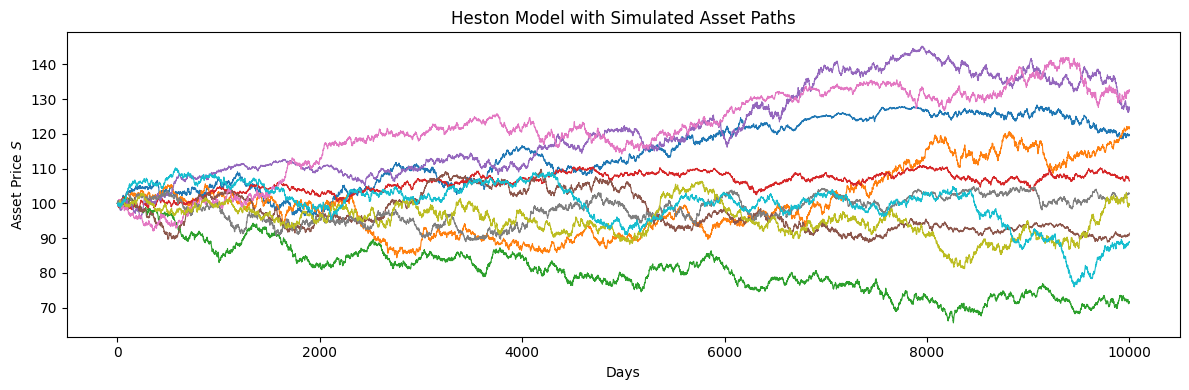

In [ ]:
""" Plotting """

# Setting up the figure
plt.figure(figsize=(12, 4))

# Plotting paths
plt.plot(paths, lw=0.8)

# Title and axes titles
plt.title('Heston Model with Simulated Asset Paths')
plt.xlabel('Days')
plt.ylabel('Asset Price $S$')

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path, bbox_inches="tight")
plt.show()